In [55]:
import json

from scipy import constants as const

import drjit as dr
import matplotlib.pyplot as plt
import numpy as np

import mitsuba as mi

# colocar el valor de spectral
mi.set_variant("cuda_ad_spectral")

from mitsuba import ScalarTransform4f as T


In [56]:
def blackbody_radiance_nm(wavelengths_nm, temperature):
    """
    Compute spectral radiance B(λ, T) of a black body
    using scipy constants.

    Args:
        wavelengths_nm: array-like of wavelengths in nanometers (nm).
        temperature:    temperature in Kelvin (K).

    Returns:
        numpy array of spectral radiance in  μW/cm²/sr/μm (microflicks)
    """
    # Convert wavelengths to meters
    wavelengths_m = np.array(wavelengths_nm, dtype=float) * 1e-9

    # Planck's law for spectral radiance: from W/m²/sr/m
    exponent = (const.h * const.c) / (wavelengths_m * const.k * temperature)
    radiance = (2 * const.h * const.c**2) / (wavelengths_m**5) / (np.exp(exponent) - 1)

    # Convert radiance from W/m²/sr/m to μW/cm²/sr/μm
    radiance = radiance * 1e-4

    return radiance

In [57]:
result_path = "../output/static/result/"
static = "../output/static/"

In [58]:
with open(static + "config_scene.json", "r") as f:
    config = json.load(f)


In [59]:
wavelengths = np.array(config["wavelengths"])
num_wavelengths = len(wavelengths)
wavelength_min = np.min(wavelengths)
wavelength_max = np.max(wavelengths)

t_aire = config["air"]['temperature']
blackbody_air = blackbody_radiance_nm(wavelengths, t_aire)  # µW/cm²/sr/µm

In [60]:
rgb = plt.imread(result_path + "rgb.png")
depth = np.load(result_path + "depth.npy")
thermal = np.load(result_path + "thermal.npy")
b_air = np.load(result_path + "blackbody_air.npy")
t_b_air = np.load(result_path + "transmittance_blackbody_air.npy")
contribution_air = np.load(result_path + "contribution_blackbody_air.npy")
tmap = np.load(result_path + "temperature_map.npy")
attenuation_air = np.loadtxt(static + "air.txt")

In [61]:
# organizar el atenuation air por longitudes de onda
order = np.argsort(attenuation_air[:, 0])
wavelengths_attenuation = attenuation_air[:, 0]
wavelengths_attenuation = wavelengths_attenuation[order]
sigma_t = attenuation_air[:, 1]
sigma_t = sigma_t[order]

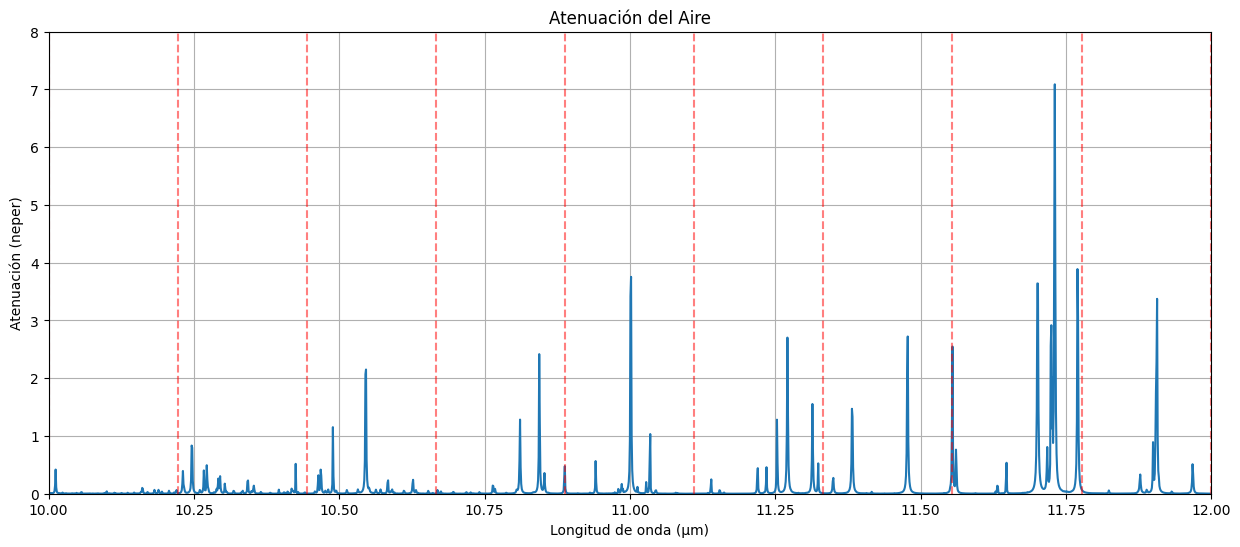

In [62]:
plt.figure(figsize=(15, 6))
plt.plot(attenuation_air[:, 0], attenuation_air[:, 1])
for wave in wavelengths:
    plt.axvline(x=wave/1000, color='red', linestyle='--', alpha=0.5)
plt.xlabel("Longitud de onda (µm)")
plt.ylabel("Atenuación (neper)")
plt.title("Atenuación del Aire")
plt.ylim(0, 8)
plt.xlim(wavelength_min/1000, wavelength_max/1000)
plt.grid()


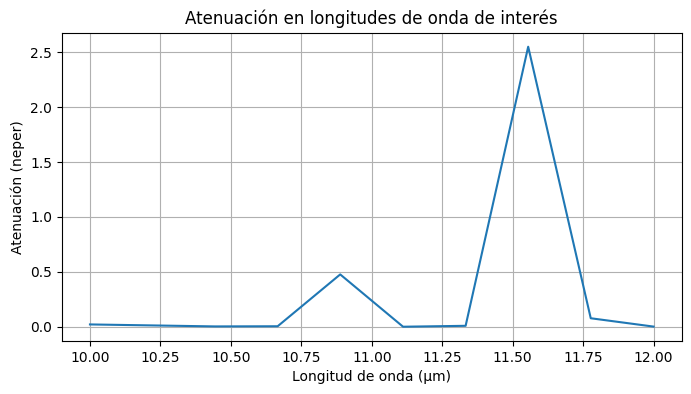

In [63]:
# Extraer la atenuación correspondiente a las longitudes de onda de interés (wavelengths_um ya existe)
interp_vals = np.interp(
    wavelengths/1000,
    wavelengths_attenuation,
    sigma_t,
    left=np.nan,
    right=np.nan
)

# Reemplazar NaN (fuera de rango) con 0 directamente
atenuacion_air = np.where(np.isnan(interp_vals), 0.0, interp_vals)

# Visualización rápida
plt.figure(figsize=(8,4))
plt.plot(wavelengths/1000, atenuacion_air)
plt.xlabel("Longitud de onda (µm)")
plt.ylabel("Atenuación (neper)")
plt.title("Atenuación en longitudes de onda de interés")
plt.grid()
plt.show()

# Objeto #1

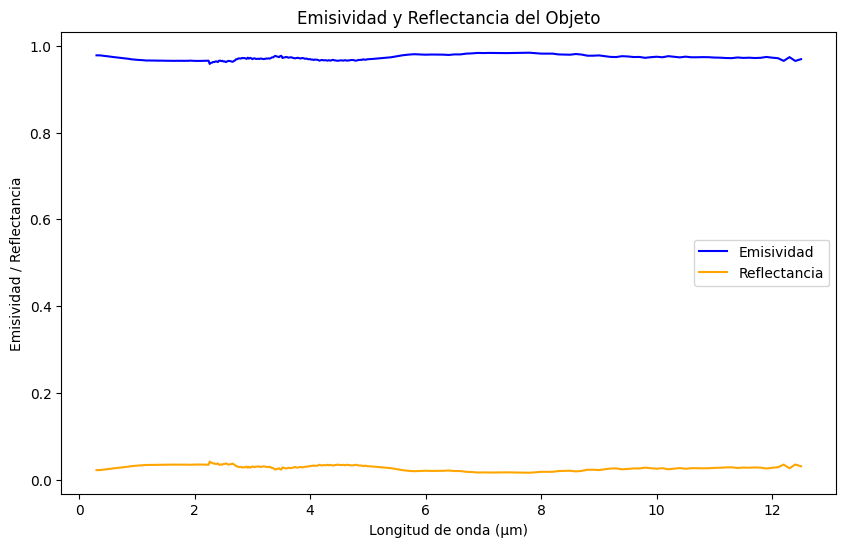

In [64]:
# objeto 1
x, y = 160, 200
firma = np.loadtxt(static + "meshes/Cube_002_1.txt", delimiter='\t')
# x, y = 90, 105
# firma = np.loadtxt(static + "meshes/Kugel_4.txt", delimiter='\t')
firma[:,1] = firma[:,1]/100
emisividad = 1-firma[:,1]
reflectancia = firma[:,1]

plt.figure(figsize=(10, 6))
plt.plot(firma[:,0], emisividad, color='blue', label='Emisividad')
plt.plot(firma[:,0], reflectancia, color='orange', label='Reflectancia')
plt.xlabel('Longitud de onda (µm)')
plt.ylabel('Emisividad / Reflectancia')
plt.title('Emisividad y Reflectancia del Objeto')
plt.legend()
plt.show()

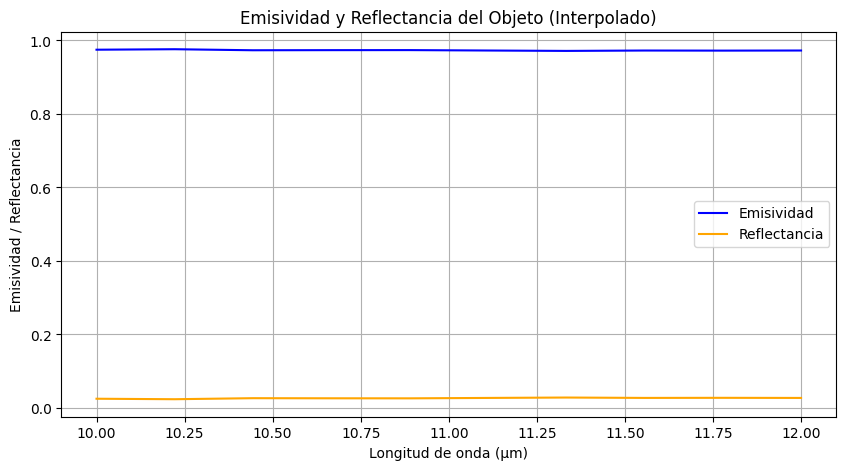

In [65]:
# Seleccionar filas de 'firma' (columna 0 en µm) que correspondan a las longitudes de onda de interés (wavelengths en nm)
wavelengths_um = wavelengths / 1000  # convertir a micrómetros

# Encontrar índice más cercano en 'firma' para cada longitud de onda solicitada
indices_firma = [int(np.argmin(np.abs(firma[:, 0] - w))) for w in wavelengths_um]

# Extraer filas seleccionadas
firma_interes = firma[indices_firma]  # columnas: [λ(µm), reflectancia]
emisividad = emisividad[indices_firma]
reflectancia = reflectancia[indices_firma]

plt.figure(figsize=(10, 5))
plt.plot(wavelengths_um, emisividad, color='blue', label='Emisividad')
plt.plot(wavelengths_um, reflectancia, color='orange', label='Reflectancia')
plt.xlabel('Longitud de onda (µm)')
plt.ylabel('Emisividad / Reflectancia')
plt.title('Emisividad y Reflectancia del Objeto (Interpolado)')
plt.legend()
plt.grid()

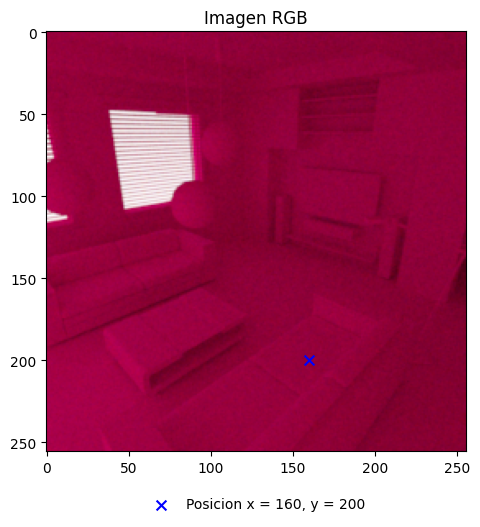

In [66]:
plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.scatter(x, y, color='blue', s=50, marker='x', label=f'Posicion x = {x}, y = {y}')
plt.title("Imagen RGB")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.subplots_adjust(bottom=0.18)
plt.show()

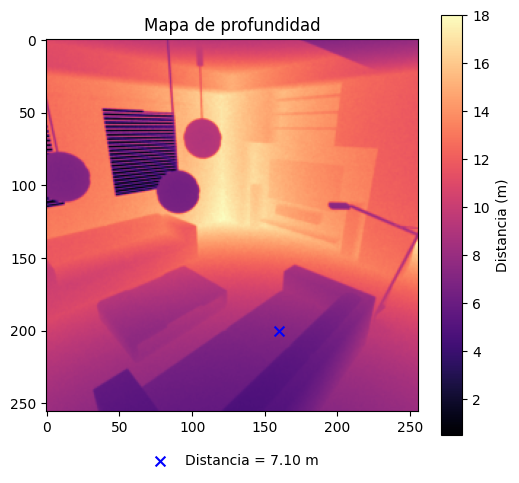

In [67]:
distancia = depth[y,x]

plt.figure(figsize=(6, 6))
plt.imshow(depth, cmap='magma')
plt.colorbar(label='Distancia (m)')
plt.title("Mapa de profundidad")
plt.scatter(x, y, color='blue', s=50, marker='x', label=f'Distancia = {distancia:.2f} m')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.subplots_adjust(bottom=0.18)
plt.show()

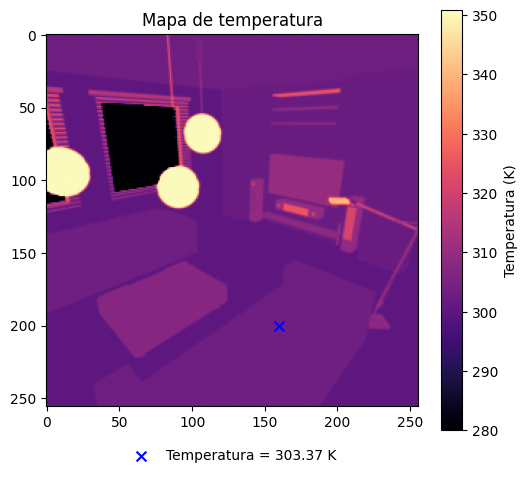

In [68]:
temperatura = tmap[y,x]

plt.figure(figsize=(6, 6))
plt.imshow(tmap, cmap='magma', vmin=t_aire)
plt.colorbar(label='Temperatura (K)')
plt.title("Mapa de temperatura")
plt.scatter(x, y, color='blue', s=50, marker='x', label=f'Temperatura = {temperatura:.2f} K')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.subplots_adjust(bottom=0.18)
plt.show()

597.20703 1248.6531


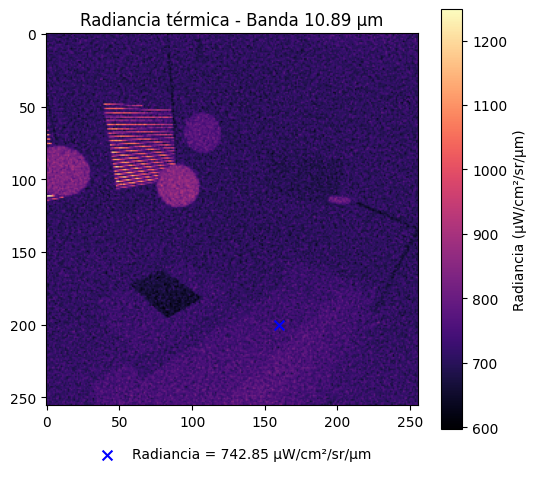

In [69]:
banda = 4

print(np.min(thermal[:,:,banda]), np.max(thermal[:,:,banda]))
plt.figure(figsize=(6, 6))
plt.imshow(thermal[:, :, banda], cmap='magma')
plt.colorbar(label='Radiancia (μW/cm²/sr/μm)')
plt.title(f"Radiancia térmica - Banda {wavelengths[banda]/1000:.2f} µm")
plt.scatter(x, y, color='blue', s=50, marker='x', label=f'Radiancia = {thermal[y,x,banda]:.2f} μW/cm²/sr/μm')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.subplots_adjust(bottom=0.18)
plt.show()

(0.0, 1.0)

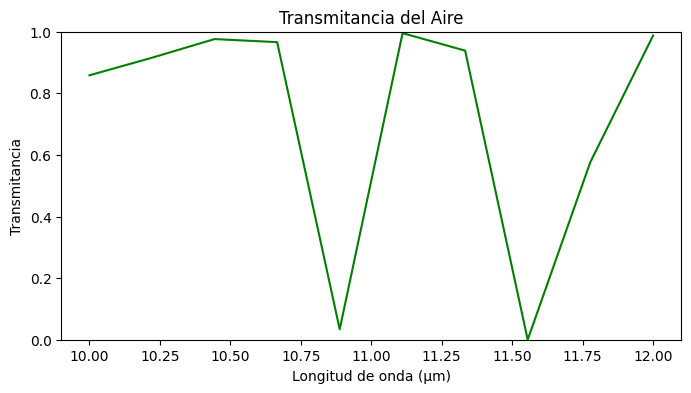

In [70]:
transmitancia = np.exp(-atenuacion_air*distancia)

plt.figure(figsize=(8,4))
plt.plot(wavelengths/1000, transmitancia, label='Transmitancia del aire', color='green')
plt.xlabel("Longitud de onda (µm)")
plt.ylabel("Transmitancia")
plt.title("Transmitancia del Aire")
plt.ylim(0, 1)

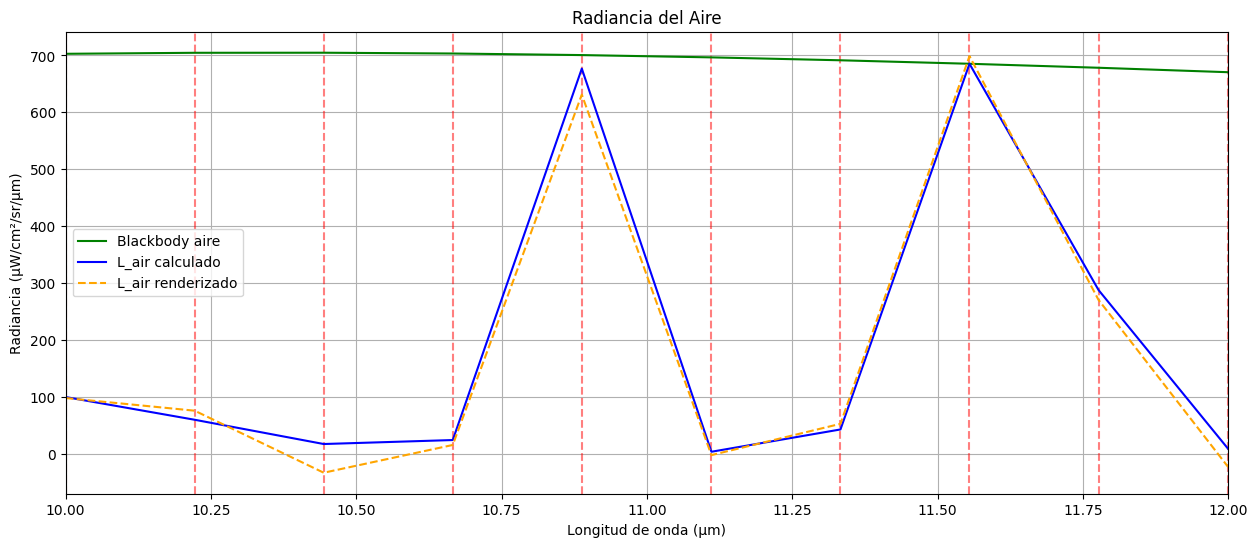

In [71]:
blackbody_air = blackbody_radiance_nm(wavelengths, t_aire)  # µW/cm²/sr/µm
transmitancia = np.exp(-atenuacion_air*distancia)
L_air = (1-transmitancia) * blackbody_air
L_air_renderizado = contribution_air[y,x,:]

plt.figure(figsize=(15, 6))
for wave in wavelengths:
    plt.axvline(x=wave/1000, color='red', linestyle='--', alpha=0.5)
plt.plot(wavelengths/1000, blackbody_air, label='Blackbody aire', color='green')
plt.plot(wavelengths/1000, L_air, label='L_air calculado', color='blue')
plt.plot(wavelengths/1000, L_air_renderizado, label='L_air renderizado', color='orange', linestyle='--')
plt.xlabel("Longitud de onda (µm)")
plt.ylabel("Radiancia (μW/cm²/sr/μm)")
plt.title("Radiancia del Aire")
plt.xlim(wavelength_min/1000, wavelength_max/1000)
plt.legend()
plt.grid()

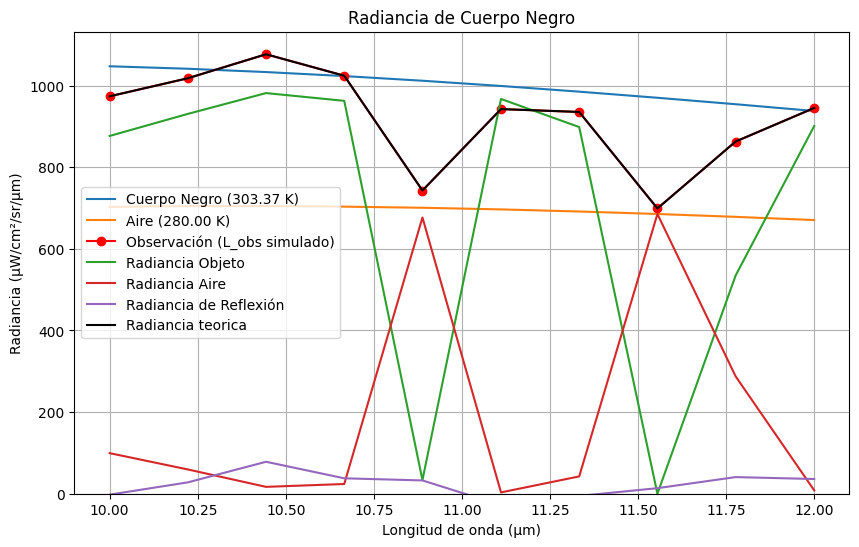

In [72]:
blackbody_air = blackbody_radiance_nm(wavelengths, t_aire)  # µW/cm²/sr/µm
blackbody = blackbody_radiance_nm(wavelengths, temperatura)  # µW/cm²/sr/µm
renderizado = thermal[y,x,:]
transmitancia = np.exp(-atenuacion_air*distancia)
emision = emisividad * blackbody
L_obj = emision * transmitancia
L_air = (1-transmitancia) * blackbody_air
L_ref = renderizado - L_obj - L_air
L_obs = L_obj + L_air + L_ref

plt.figure(figsize=(10, 6))
plt.plot(wavelengths/1000, blackbody, label=f'Cuerpo Negro ({temperatura:.2f} K)')
plt.plot(wavelengths/1000, blackbody_air, label=f'Aire ({t_aire:.2f} K)')
plt.plot(wavelengths/1000, renderizado, 'o-', color='red', label='Observación (L_obs simulado)')
plt.plot(wavelengths/1000, L_obj, label='Radiancia Objeto')
plt.plot(wavelengths/1000, L_air, label='Radiancia Aire')
plt.plot(wavelengths/1000, L_ref, label='Radiancia de Reflexión')
plt.plot(wavelengths/1000, L_obs, label='Radiancia teorica', color='black')
plt.xlabel('Longitud de onda (µm)')
plt.ylabel('Radiancia (µW/cm²/sr/µm)')
plt.title('Radiancia de Cuerpo Negro')
plt.legend()
plt.ylim(0, None)
plt.grid()
